In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = {
    'Temperature':[25,27,28,30,31,33,35,34,32,29,
                   26,24,23,25,28,30,32,34,36,35,
                   33,31,29,27,26,28,30,32,34,35],

    'Humidity':[60,58,55,52,50,48,45,47,50,54,
                58,62,65,60,56,53,50,46,43,45,
                48,52,55,58,60,57,54,50,47,44],

    'Load':[220,230,240,255,265,280,300,295,275,250,
            225,215,210,220,245,260,275,295,310,305,
            285,265,250,235,225,240,255,275,295,305]
}

df = pd.DataFrame(data)

df.head()

,Temperature,Humidity,Load
0,25,60,220
1,27,58,230
2,28,55,240
3,30,52,255
4,31,50,265


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (30, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Temperature  30 non-null     int64
 1   Humidity     30 non-null     int64
 2   Load         30 non-null     int64
dtypes: int64(3)
memory usage: 852.0 bytes


In [4]:
df.describe()

,Temperature,Humidity,Load
count,30.000000,30.000000,30.000000
mean,30.066667,52.733333,260.000000
std,3.666562,5.865935,30.257515
min,23.000000,43.000000,210.000000
25%,27.250000,48.000000,236.250000
50%,30.000000,52.500000,257.500000
75%,33.000000,57.750000,283.750000
max,36.000000,65.000000,310.000000


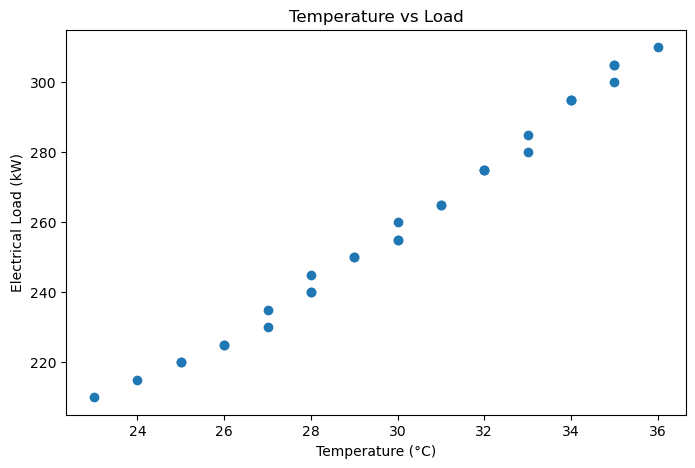

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(df['Temperature'],df['Load'])

plt.xlabel("Temperature (°C)")
plt.ylabel("Electrical Load (kW)")
plt.title("Temperature vs Load")

plt.show()

In [6]:
X = df[['Temperature','Humidity']]

y = df['Load']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 24
Testing Samples: 6


In [8]:
model = LinearRegression()

model.fit(X_train,y_train)

print("Model Training Completed")

Model Training Completed


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[275.82313713 259.44269915 234.90258488 292.14248971 275.82313713
 251.22193746]


In [10]:
results = pd.DataFrame({
    'Actual Load':y_test,
    'Predicted Load':y_pred
})

results

,Actual Load,Predicted Load
27,275,275.823137
15,260,259.442699
23,235,234.902585
17,295,292.142490
8,275,275.823137
9,250,251.221937


In [11]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("MAE =", round(mae,2))
print("MSE =", round(mse,2))
print("R² =", round(r2,4))

MAE = 1.06
MSE = 1.89
R² = 0.995


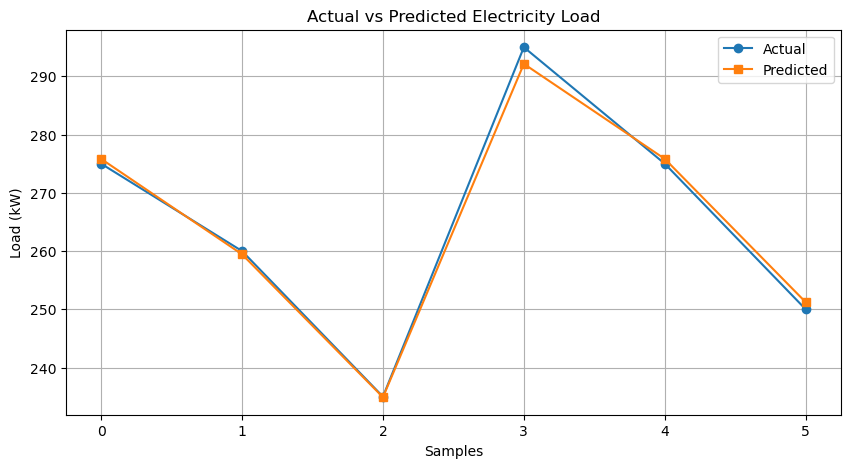

In [12]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,
         marker='o',
         label='Actual')

plt.plot(y_pred,
         marker='s',
         label='Predicted')

plt.xlabel("Samples")

plt.ylabel("Load (kW)")

plt.title("Actual vs Predicted Electricity Load")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
new_data = [[37,40]]

prediction = model.predict(new_data)

print("Predicted Load =", round(prediction[0],2),"kW")

Predicted Load = 316.62 kW


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
import joblib

joblib.dump(model,"load_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
